In [ ]:
# ============================================================
# INSTALL PACKAGES (Run once)
# ============================================================

!pip install --quiet gspread google-auth-oauthlib openpyxl pulp matplotlib

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import gspread
import pulp
import matplotlib.pyplot as plt
from google.colab import auth
import google.auth


In [ ]:
# ============================================================
# GOOGLE AUTHENTICATION
# ============================================================

auth.authenticate_user()
creds, _ = google.auth.default()
gc = gspread.authorize(creds)

# ============================================================
# OPEN GOOGLE SHEET
# ============================================================

sheet_url = "https://docs.google.com/spreadsheets/d/18XhbXKLsZv0hTvyudB95SZXSEatBNZXl-NuiP6zZqvo/edit?usp=sharing"
spreadsheet = gc.open_by_url(sheet_url)


In [ ]:
# Step 0: Install required packages
!pip install --quiet gspread google-auth-oauthlib

# Step 1: Import libraries
import gspread
from google.colab import auth
from google.auth import default

# Step 2: Authenticate
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# Step 3: Open your spreadsheet
SPREADSHEET_URL = "https://docs.google.com/spreadsheets/d/18XhbXKLsZv0hTvyudB95SZXSEatBNZXl-NuiP6zZqvo/edit?usp=sharing"
sh = gc.open_by_url(SPREADSHEET_URL)

# Step 4: Preview sheets
all_sheets = sh.worksheets()
print("All sheets in the spreadsheet:")
for idx, sheet in enumerate(all_sheets, start=1):
    print(f"{idx}. {sheet.title}")

# Keep the first 5 sheets
sheets_to_keep = all_sheets[:5]
sheets_to_delete = [sheet for sheet in all_sheets if sheet not in sheets_to_keep]

print("\nSheets that will be deleted:")
for sheet in sheets_to_delete:
    print(sheet.title)

# Step 5: Delete sheets
for sheet in sheets_to_delete:
    print(f"Deleting sheet: {sheet.title}")
    sh.del_worksheet(sheet)

print("\nDeletion complete! Only the first 5 sheets remain.")




All sheets in the spreadsheet:
1. Privet data
2. Budget
3. Slope Values
4. Distance Values
5. K_ij_Matrix_10x10
6. neighbor_influence_t0
7. H_function_t0
8. new_population_t0
9. selected_cells_t0
10. after_treatment_t0
11. neighbor_influence_t1
12. H_function_t1
13. new_population_t1
14. selected_cells_t1
15. after_treatment_t1
16. neighbor_influence_t2
17. H_function_t2
18. new_population_t2
19. selected_cells_t2
20. after_treatment_t2

Sheets that will be deleted:
neighbor_influence_t0
H_function_t0
new_population_t0
selected_cells_t0
after_treatment_t0
neighbor_influence_t1
H_function_t1
new_population_t1
selected_cells_t1
after_treatment_t1
neighbor_influence_t2
H_function_t2
new_population_t2
selected_cells_t2
after_treatment_t2
Deleting sheet: neighbor_influence_t0
Deleting sheet: H_function_t0
Deleting sheet: new_population_t0
Deleting sheet: selected_cells_t0
Deleting sheet: after_treatment_t0
Deleting sheet: neighbor_influence_t1
Deleting sheet: H_function_t1
Deleting sheet: n

In [ ]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================




# ============================================================
# READ 2D SHEET
# ============================================================

def read_sheet_2d(sheet_name):
    ws = spreadsheet.worksheet(sheet_name)
    values = ws.get_all_values()
    return pd.DataFrame(values).astype(float).to_numpy()


# ============================================================
# READ 1D SHEET (Flatten)
# ============================================================

def read_sheet_1d(sheet_name):
    ws = spreadsheet.worksheet(sheet_name)
    values = ws.get_all_values()
    return [float(cell) for row in values for cell in row]


# ============================================================
# WRITE 2D SHEET
# ============================================================

def write_sheet(sheet_name, data_2d):
    try:
        spreadsheet.del_worksheet(spreadsheet.worksheet(sheet_name))
    except:
        pass

    rows, cols = len(data_2d), len(data_2d[0])
    ws_new = spreadsheet.add_worksheet(title=sheet_name,
                                       rows=rows,
                                       cols=cols)
    ws_new.update(data_2d)


In [ ]:
# =========================================================
# Logistic Carrying Capacity Estimation (10x10 Grid)
# EXACT REPRODUCTION VERSION
# =========================================================

# =========================================================
# READ DATA USING YOUR EXISTING HELPERS
# =========================================================

df_density = read_sheet_2d("Privet data")
df_slope   = read_sheet_2d("Slope Values")
df_dist    = read_sheet_2d("Distance Values")

grid_shape = df_density.shape   # (10,10)

density = df_density.flatten()
slope   = df_slope.flatten()
dist    = df_dist.flatten()

print("Density shape :", df_density.shape)
print("Slope shape   :", df_slope.shape)
print("Distance shape:", df_dist.shape)

# =========================================================
# REMOVE NoData (-9999)
# =========================================================

valid_mask = density != -9999

density = density[valid_mask]
slope   = slope[valid_mask]
dist    = dist[valid_mask]

# =========================================================
# CREATE DATAFRAME
# =========================================================

data = pd.DataFrame({
    "Plant_Density": density,
    "Slope": slope,
    "Dist": dist
})

# =========================================================
# LOGISTIC TRANSFORMATION (IDENTICAL TO OLD CODE)
# =========================================================

K_max = 1.0

K_frac = data["Plant_Density"] / K_max
K_frac = np.clip(K_frac, 1e-3, 1 - 1e-3)   # IMPORTANT

data["logit_K"] = np.log(K_frac / (1 - K_frac))

# =========================================================
# STANDARDIZATION (NUMPY VERSION — ddof=0)
# =========================================================

def standardize(x):
    return (x - np.mean(x)) / np.std(x)

data["Slope_std"] = standardize(data["Slope"])
data["Dist_std"]  = standardize(data["Dist"])

# =========================================================
# FIT LINEAR REGRESSION
# =========================================================

import statsmodels.api as sm

X = data[["Slope_std", "Dist_std"]]
X = sm.add_constant(X)

Y = data["logit_K"]

model = sm.OLS(Y, X)
result = model.fit()

print("\nEstimated coefficients for K_ij logistic model:\n")
print(f"β0 (Intercept) : {result.params['const']:.6f}")
print(f"β1 (Slope)     : {result.params['Slope_std']:.6f}")
print(f"β2 (Distance)  : {result.params['Dist_std']:.6f}")

# =========================================================
# COMPUTE K_ij
# =========================================================

beta_0 = result.params["const"]
beta_1 = result.params["Slope_std"]
beta_2 = result.params["Dist_std"]

data["K_ij"] = K_max / (
    1 + np.exp(
        - (beta_0
           + beta_1 * data["Slope_std"]
           + beta_2 * data["Dist_std"])
    )
)

# =========================================================
# RESHAPE BACK TO 10x10 GRID
# =========================================================

K_ij_matrix = data["K_ij"].to_numpy().reshape(grid_shape)

# =========================================================
# WRITE TO GOOGLE SHEET USING YOUR HELPER
# =========================================================

write_sheet("K_ij_Matrix_10x10", K_ij_matrix.tolist())

print("\n✅ K_ij matrix successfully written to Google Sheet.")


Density shape : (10, 10)
Slope shape   : (10, 10)
Distance shape: (10, 10)

Estimated coefficients for K_ij logistic model:

β0 (Intercept) : -5.663539
β1 (Slope)     : 0.502851
β2 (Distance)  : -1.541939

✅ K_ij matrix successfully written to Google Sheet.


In [ ]:
# ============================================================
# MATHEMATICAL FUNCTIONS
# ============================================================





# ============================================================
# NEIGHBOR INFLUENCE FUNCTION
# ============================================================

def compute_neighbor_influence(grid, lamda, mu):
    rows, cols = grid.shape
    output = np.zeros_like(grid)

    directions = [(-1,-1),(-1,0),(-1,1),
                  (0,-1),(0,1),
                  (1,-1),(1,0),(1,1)]

    for i in range(rows):
        for j in range(cols):
            influence = 0.0
            for di,dj in directions:
                ni,nj = i+di, j+dj
                if 0 <= ni < rows and 0 <= nj < cols:
                    influence += (lamda + mu) * grid[ni,nj]
            output[i,j] = influence

    return output


In [ ]:
# ============================================================
# LOAD STATIC PARAMETERS
# ============================================================

lamda = 0.0488
mu = 0.1875
gamma = 0.3
alpha = 0.7  #0.5
beta = 0.3   #0.5
T = 3
B = 120               # constant budget each time step
r = 0.5               # intrinsic growth rate

# Load static sheets
K_ij = read_sheet_2d("K_ij_Matrix_10x10")

b_list = read_sheet_1d("Budget")
slope_list = read_sheet_1d("Slope Values")
dist_list = read_sheet_1d("Distance Values")


# Convert to Dictionaries

num_cells = len(b_list)
J = list(range(num_cells))

b = {j:b_list[j] for j in J}
slope = {j:slope_list[j] for j in J}
dist = {j:dist_list[j] for j in J}



At t = 0, selected Pareto solution = D_6 (Python index = 5)
At t = 1, selected Pareto solution = D_12 (Python index = 11)
At t = 2, selected Pareto solution = D_6 (Python index = 5)

TIME STEP t = 0
Available Budget (constant): 120
    epsilon         f1      f2  Used Budget  Remaining Budget
0       1.0  36.406222  0.9525         58.0              62.0
1       1.5  29.575200  1.4025         64.0              56.0
2       2.0  23.214489  1.9050         67.0              53.0
3       2.5  18.223644  2.3975         72.0              48.0
4       3.0  14.232800  2.8900         74.0              46.0
5       3.5  11.292178  3.3825         85.0              35.0
6       4.0   8.611822  3.9900         95.0              25.0
7       4.5   6.091289  4.4825        101.0              19.0
8       5.0   4.410933  4.9750        106.0              14.0
9       5.5   2.940622  5.4000        110.0              10.0
10      6.0   1.680356  5.9025        120.0               0.0
11      6.5   1.680356  

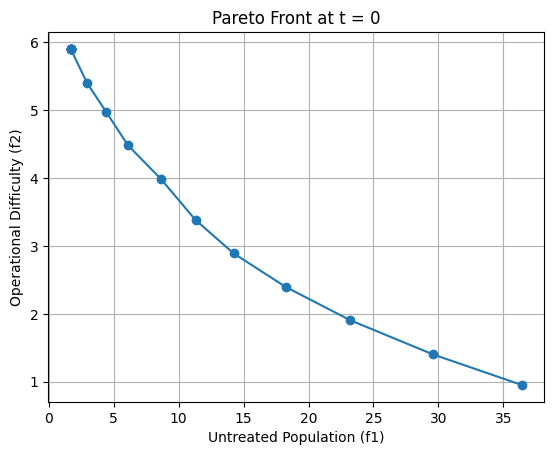


TIME STEP t = 1
Available Budget (constant): 120
    epsilon        f1      f2  Used Budget  Remaining Budget
0       1.0  5.144248  0.9850         11.0             109.0
1       1.5  3.663040  1.4100         15.0             105.0
2       2.0  2.346520  1.9125         25.0              95.0
3       2.5  1.658825  2.4825         46.0              74.0
4       3.0  1.425872  2.9750         55.0              65.0
5       3.5  1.009361  3.4950         58.0              62.0
6       4.0  0.791479  3.8675         64.0              56.0
7       4.5  0.580187  4.3500         68.0              52.0
8       5.0  0.514108  4.9725         78.0              42.0
9       5.5  0.450811  5.4600         81.0              39.0
10      6.0  0.395567  5.9625        114.0               6.0
11      6.5  0.338248  6.4650         96.0              24.0
12      7.0  0.283824  6.9675        102.0              18.0
13      7.5  0.228138  7.4700        114.0               6.0
14      8.0  0.180123  7.9725      

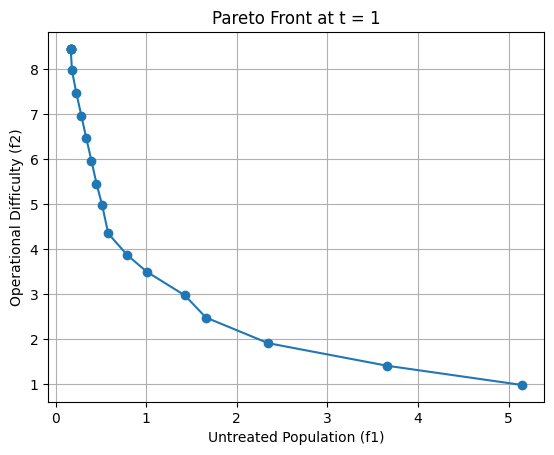


TIME STEP t = 2
Available Budget (constant): 120
   epsilon        f1      f2  Used Budget  Remaining Budget
0      1.5  0.337210  1.4550         58.0              62.0
1      2.0  0.267747  1.9050         69.0              51.0
2      2.5  0.193198  2.4750         82.0              38.0
3      3.0  0.132771  2.9775         89.0              31.0
4      3.5  0.106159  3.4800        103.0              17.0
5      4.0  0.082077  3.9825        111.0               9.0
6      4.5  0.058611  4.4850        119.0               1.0
7      5.0  0.039433  4.9625        120.0               0.0
8      5.5  0.030170  5.2400        119.0               1.0
9      6.0  0.030170  5.2400        119.0               1.0


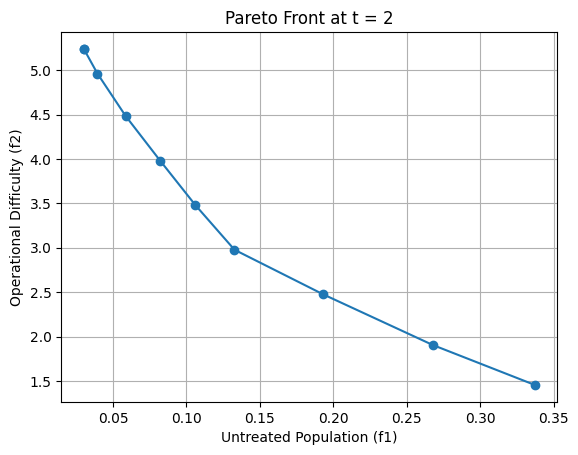

In [ ]:
# ============================================================
# DYNAMIC SIMULATION (CONSTANT BUDGET) WITH CUMULATIVE LOGISTIC UPDATE
# AND STRICT POSITIVE-POPULATION SELECTION
# ============================================================

# Read initial population grid from Google Sheet
after_treatment_prev = read_sheet_2d("Privet data")
all_pareto_results = {}

# --------------------------------------------
# Manual selection strategy per time step
# Key = time step, Value = solution index
# --------------------------------------------
selected_solution_index = {
    0: 6,
    1: 12,
    2: 6,
    # add more as needed
}

for t, idx in selected_solution_index.items():
    python_idx = idx - 1
    print(f"At t = {t}, selected Pareto solution = D_{idx} (Python index = {python_idx})")

for t in range(T):
    print("\n================================================")
    print(f"TIME STEP t = {t}")
    print("Available Budget (constant):", B)
    print("================================================")

    # --------------------------------------------
    # STEP 1: Neighbor Influence
    # --------------------------------------------
    neighbor_output = compute_neighbor_influence(after_treatment_prev, lamda, mu)
    write_sheet(f"neighbor_influence_t{t}", neighbor_output.tolist())

    # --------------------------------------------
    # STEP 2: H function
    # --------------------------------------------
    h_grid = after_treatment_prev + (8/9) * neighbor_output
    write_sheet(f"H_function_t{t}", h_grid.tolist())

    # --------------------------------------------
    # STEP 3: Logistic Update
    # --------------------------------------------
    exp_rt = np.exp(r * t)  # one-step growth

    if t == 0:
        # usual logistic update for t=0
        new_a_ij = (exp_rt * K_ij * h_grid) / (K_ij + h_grid * (exp_rt - 1))
    else:
        # cumulative logistic update for t>=1
        new_a_ij = after_treatment_prev + (exp_rt * K_ij * h_grid) / (K_ij + h_grid * (exp_rt - 1))

    # Apply real-world threshold: set very small populations to zero
    threshold_value = 0.009
    new_a_ij = np.where(new_a_ij < threshold_value, 0, new_a_ij)

    # Save new population to Google Sheet
    write_sheet(f"new_population_t{t}", new_a_ij.tolist())

    # Flatten for optimization
    a_list = new_a_ij.flatten()
    a = {j: a_list[j] for j in J}

    # Only consider strictly positive population cells
    invaded_cells = [j for j in J if a[j] > 0]

    if not invaded_cells:
        print(f"No invaded cells remaining at t={t}. Simulation ends.")
        break

    # --------------------------------------------
    # STEP 4: Pareto Optimization via epsilon constraint
    # --------------------------------------------
    f2_max = sum(alpha * slope[j] + beta * dist[j] for j in invaded_cells)
    epsilon_values = np.arange(0, f2_max + 0.5, 0.5)

    results = []
    solutions = []

    for eps in epsilon_values:
        prob = pulp.LpProblem("Dynamic_Model", pulp.LpMinimize)
        x = pulp.LpVariable.dicts("x", J, cat="Binary")

        # Objective f1: untreated population
        prob += pulp.lpSum([a[j] * (1 - x[j]) for j in invaded_cells])

        total_population = sum(a[j] for j in invaded_cells)

        # Gamma constraint
        prob += pulp.lpSum([a[j] * x[j] for j in invaded_cells]) >= gamma * total_population

        # Constant budget
        prob += pulp.lpSum([b[j] * x[j] for j in invaded_cells]) <= B

        # Epsilon constraint
        prob += pulp.lpSum([(alpha * slope[j] + beta * dist[j]) * x[j] for j in invaded_cells]) <= eps

        # Ensure zero-population cells are never selected
        for j in J:
            if a[j] == 0:
                prob += x[j] == 0

        prob.solve(pulp.PULP_CBC_CMD(msg=0))

        if pulp.LpStatus[prob.status] == 'Optimal':
            f1 = pulp.value(prob.objective)
            f2 = sum((alpha * slope[j] + beta * dist[j]) * (x[j].varValue or 0) for j in invaded_cells)
            used_budget = sum(b[j] * (x[j].varValue or 0) for j in invaded_cells)
            solution = {j: (x[j].varValue or 0) for j in J}

            results.append({
                'epsilon': eps,
                'f1': f1,
                'f2': f2,
                'Used Budget': used_budget,
                'Remaining Budget': B - used_budget
            })
            solutions.append(solution)

    results_df = pd.DataFrame(results)
    all_pareto_results[t] = results_df.copy()

    if results_df.empty:
        print(f"No feasible solutions at t={t}.")
        break

    # --------------------------------------------
    # PRINT & PLOT PARETO FRONT
    # --------------------------------------------
    print(results_df)
    plt.figure()
    plt.plot(results_df['f1'], results_df['f2'], marker='o')
    plt.xlabel("Untreated Population (f1)")
    plt.ylabel("Operational Difficulty (f2)")
    plt.title(f"Pareto Front at t = {t}")
    plt.grid(True)
    plt.show()

    # --------------------------------------------
    # CHOOSE SOLUTION BASED ON TIME STEP
    # --------------------------------------------
    sol_index = selected_solution_index.get(t, 0)  # default to first solution if t not specified
    first_sol = solutions[sol_index]
    binary_vector = np.array([first_sol[j] for j in J])
    binary_grid = binary_vector.reshape(after_treatment_prev.shape)
    write_sheet(f"selected_cells_t{t}", binary_grid.tolist())

    # --------------------------------------------
    # Apply treatment: remove selected cells
    # --------------------------------------------
    after_treatment = np.where(binary_grid == 1, 0, new_a_ij)
    write_sheet(f"after_treatment_t{t}", after_treatment.tolist())

    # --------------------------------------------
    # Update for next iteration
    # --------------------------------------------
    after_treatment_prev = after_treatment.copy()

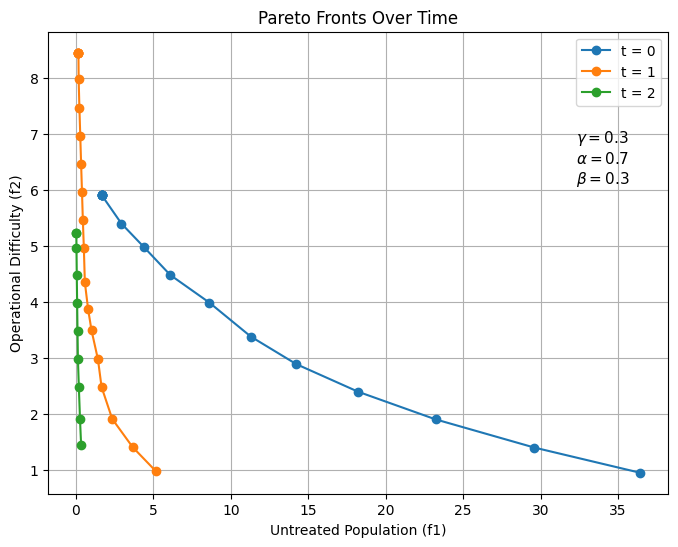

In [ ]:
# ============================================================
# PLOT ALL PARETO CURVES TOGETHER
# ============================================================

plt.figure(figsize=(8,6))

for t, df in all_pareto_results.items():
    if not df.empty:
        plt.plot(df['f1'], df['f2'],
                 marker='o',
                 label=f't = {t}')

plt.xlabel("Untreated Population (f1)")
plt.ylabel("Operational Difficulty (f2)")
plt.title("Pareto Fronts Over Time")

# Store legend in a variable
legend = plt.legend()
plt.grid(True)

# ----------- ADD PARAMETER BOX -----------

param_text = (
    f"$\\gamma = {gamma}$\n"
    f"$\\alpha = {alpha}$\n"
    f"$\\beta = {beta}$"
)

# Draw the canvas to get correct legend position
plt.gcf().canvas.draw()

# Get legend bounding box in axis coordinates
bbox = legend.get_window_extent()
bbox = bbox.transformed(plt.gca().transAxes.inverted())

# Place text slightly below legend
plt.text(bbox.x0, bbox.y0 - 0.05,
         param_text,
         transform=plt.gca().transAxes,
         fontsize=11,
         verticalalignment='top')

plt.show()
